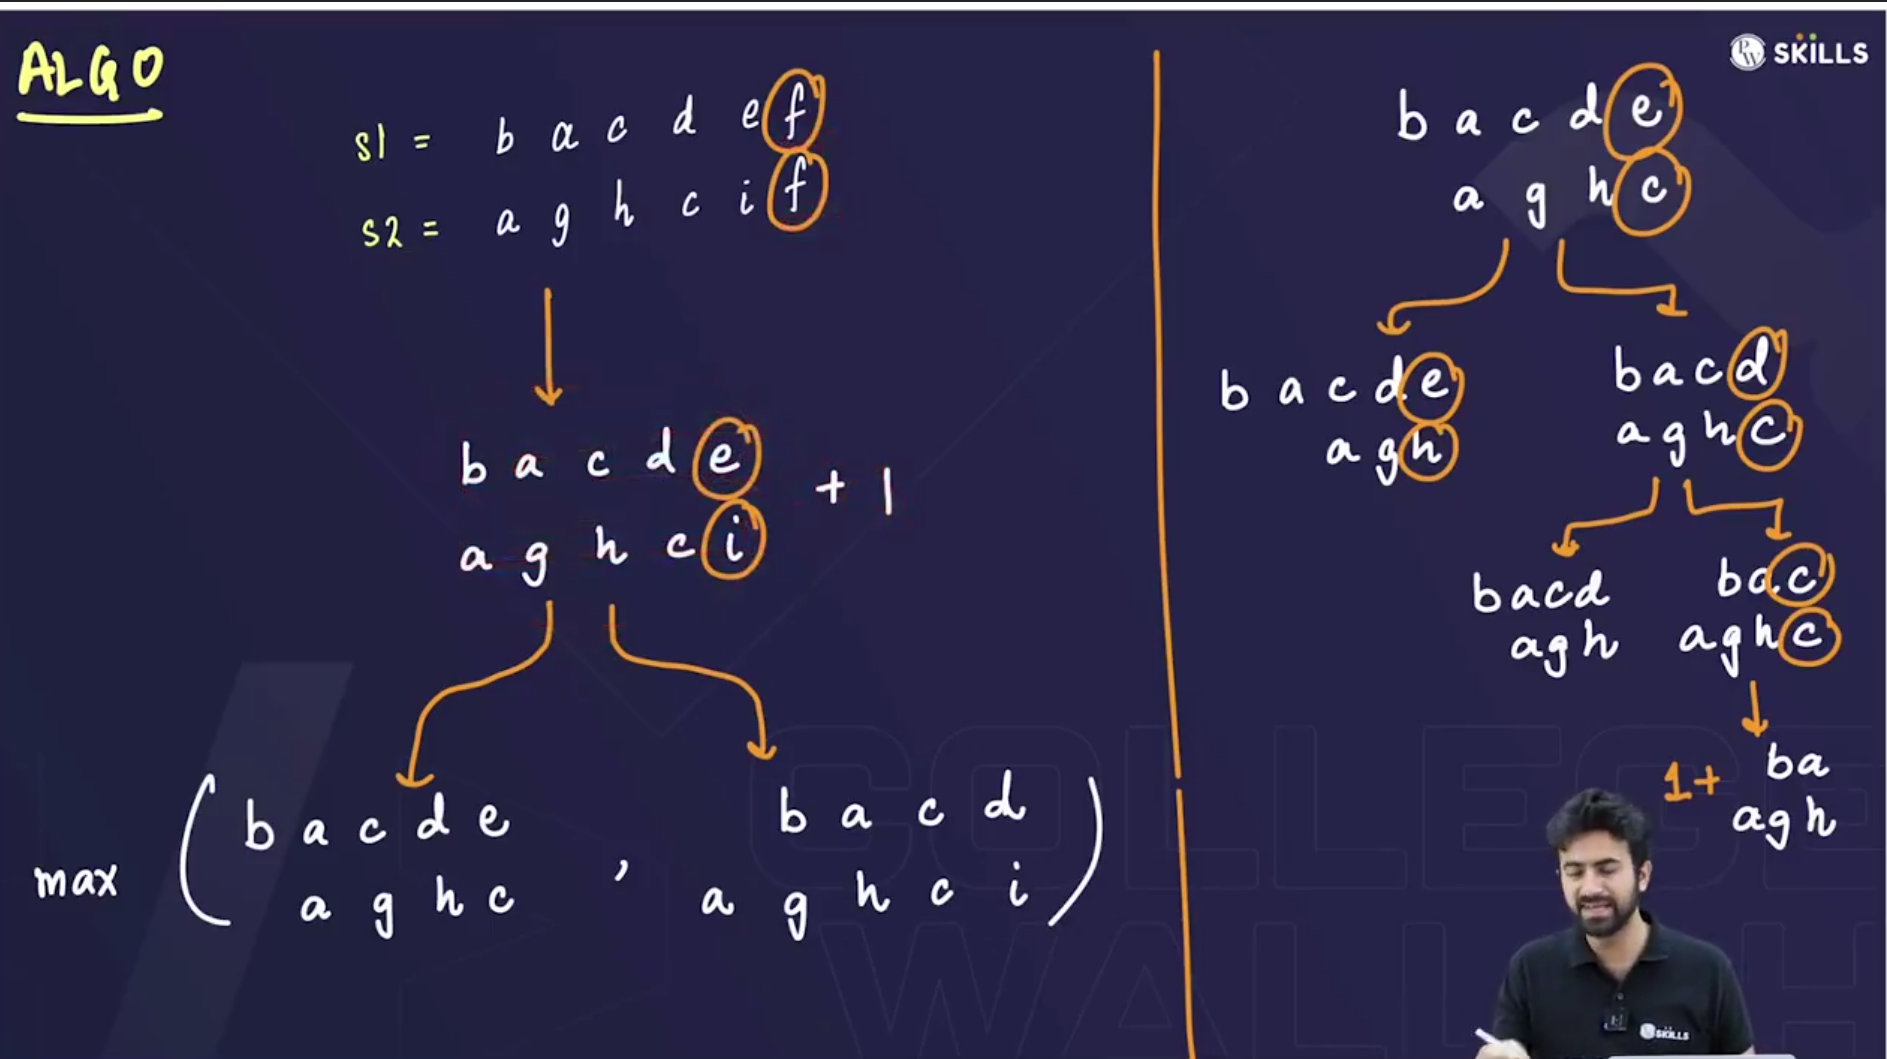

In [1]:
# Recursion
class Solution:
    def longestCommonSubsequence(self, a: str, b: str) -> int:
        m = len(a)
        n = len(b)

        if m == 0 or n == 0:
            return 0

        a2 = a[0:m-1]
        b2 = b[0:n-1]

        if a[m-1] == b[n-1]:
            return 1 + self.longestCommonSubsequence(a2, b2)
        else:
            return max(
                self.longestCommonSubsequence(a, b2),
                self.longestCommonSubsequence(a2, b)
            )

In [2]:
text1 = "abcde"
text2 = "ace" 

obj = Solution()
obj.longestCommonSubsequence(text1,text2)

3

In [5]:
class Solution:
    def LCS(self,i,j,a,b):
        if i < 0 or j < 0:
            return 0

        if a[i] == b[j]:
            return 1 + self.LCS(i-1,j-1,a, b)
        else:
            return max(
                self.LCS(i-1,j,a, b),
                self.LCS(i-1,j,a, b)
            )
    def longestCommonSubsequence(self, a: str, b: str) -> int:
        m = len(a)
        n = len(b)

        return self.LCS(m-1,n-1,a,b)

In [ ]:
text1 = "abcde"
text2 = "ace" 

obj = Solution()
obj.longestCommonSubsequence(text1,text2)

3

# `Memoization`

In [ ]:
class Solution:
    def lcs(self, i, j, a, b, dp):
        # Base case
        if i < 0 or j < 0:
            return 0

        # Memoization
        if dp[i][j] != -1:
            return dp[i][j]

        # Characters match
        if a[i] == b[j]:
            dp[i][j] = 1 + self.lcs(i - 1, j - 1, a, b, dp)
        else:
            dp[i][j] = max(
                self.lcs(i - 1, j, a, b, dp),
                self.lcs(i, j - 1, a, b, dp)
            )E

        return dp[i][j]

    def longestCommonSubsequence(self, text1: str, text2: str) -> int:
        m, n = len(text1), len(text2)

        dp = [[-1] * n for _ in range(m)]

        return self.lcs(m - 1, n - 1, text1, text2, dp)

In [8]:
text1 = "abcde"
text2 = "ace" 

obj = Solution()
obj.longestCommonSubsequence(text1,text2)

3

# `Tabulation`

In [ ]:
class Solution:
    def longestCommonSubsequence(self, text1: str, text2: str) -> int:
        m, n = len(text1), len(text2)

        if m == 0 or n == 0:
            return 0

        dp = [[0] * n for _ in range(m)]

        for i in range(m):
            for j in range(n):

                p = dp[i - 1][j - 1] if i >= 1 and j >= 1 else 0
                q = dp[i][j - 1] if j >= 1 else 0
                r = dp[i - 1][j] if i >= 1 else 0

                if text1[i] == text2[j]:
                    dp[i][j] = 1 + p
                else:
                    dp[i][j] = max(q, r)

        return dp[m - 1][n - 1]

In [10]:
text1 = "abcde"
text2 = "ace" 

obj = Solution()
obj.longestCommonSubsequence(text1,text2)

3

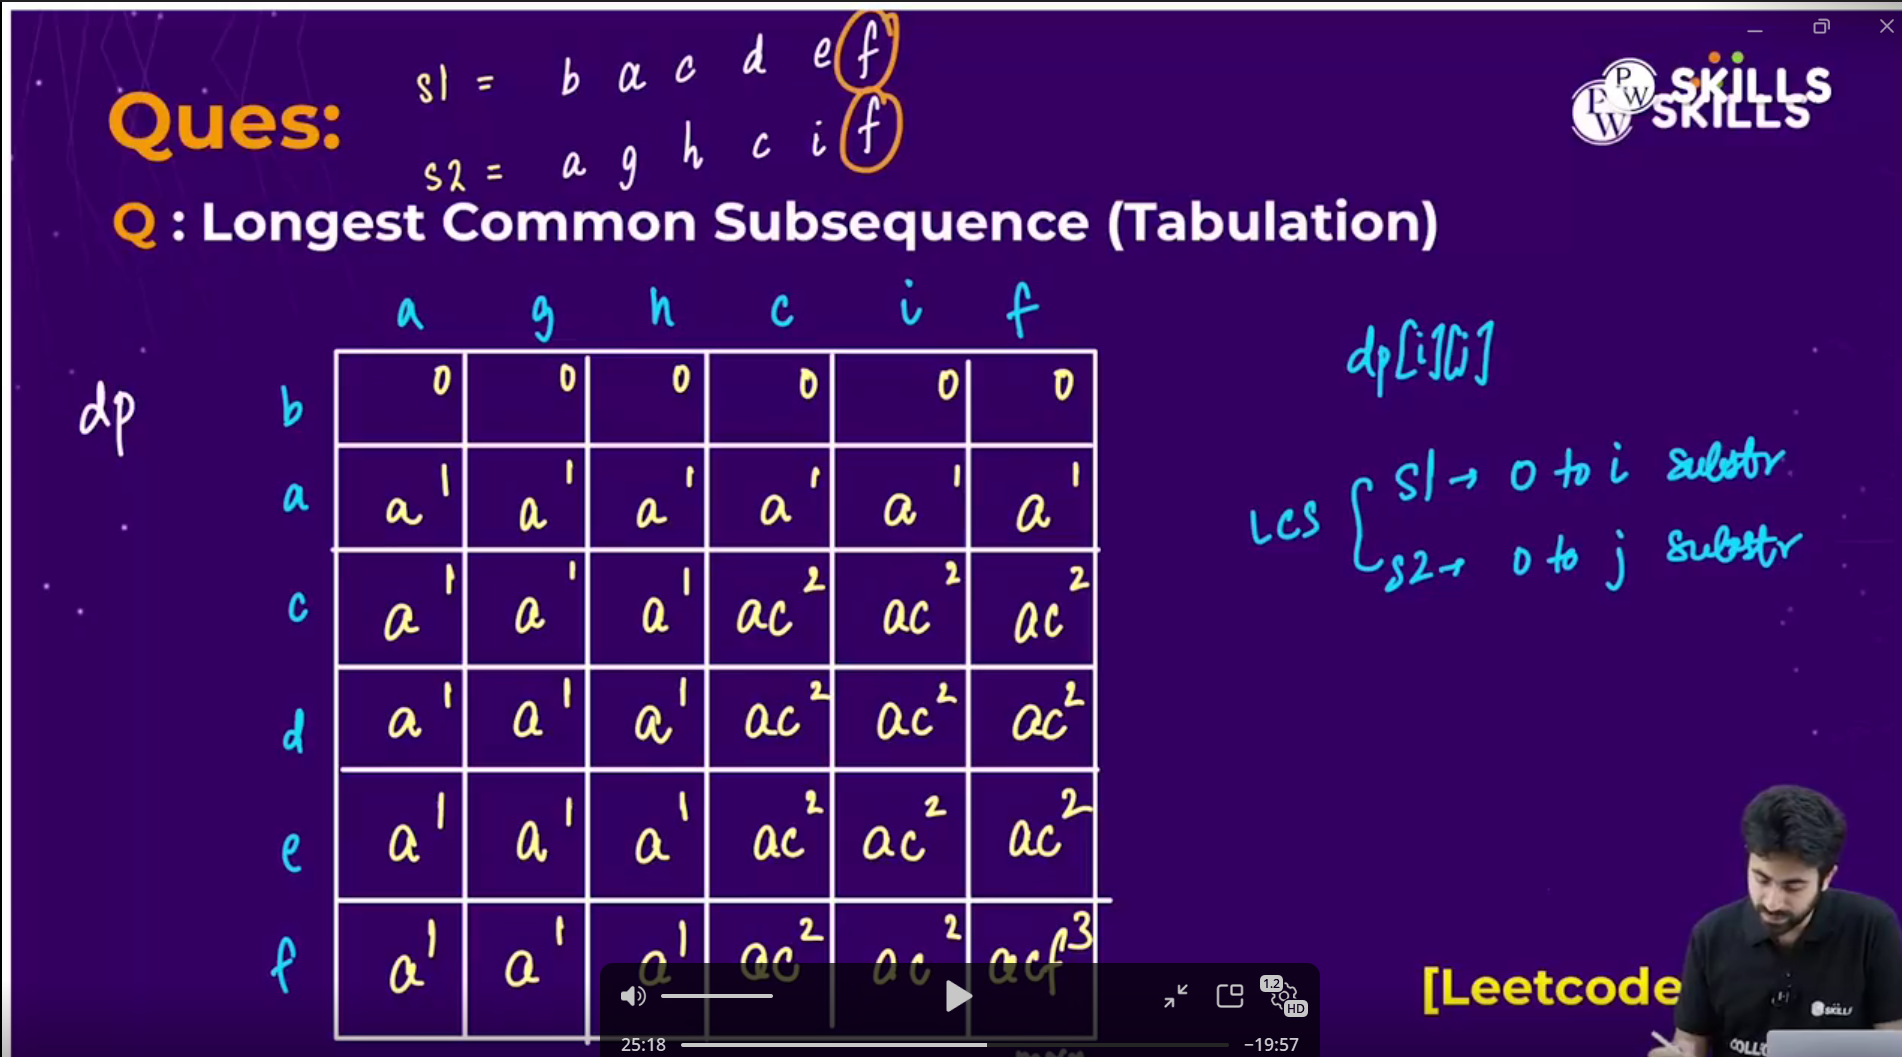

In [ ]:
class Solution:
    def longestCommonSubsequence(self, text1: str, text2: str) -> int:
        m, n = len(text1), len(text2)

        dp = [[0] * (n + 1) for _ in range(m + 1)]

        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if text1[i - 1] == text2[j - 1]:
                    dp[i][j] = 1 + dp[i - 1][j - 1]
                else:
                    dp[i][j] = max(dp[i][j - 1], dp[i - 1][j])

        
        return dp[m][n]

In [12]:
text1 = "abcde"
text2 = "ace" 

obj = Solution()
obj.longestCommonSubsequence(text1,text2)

3

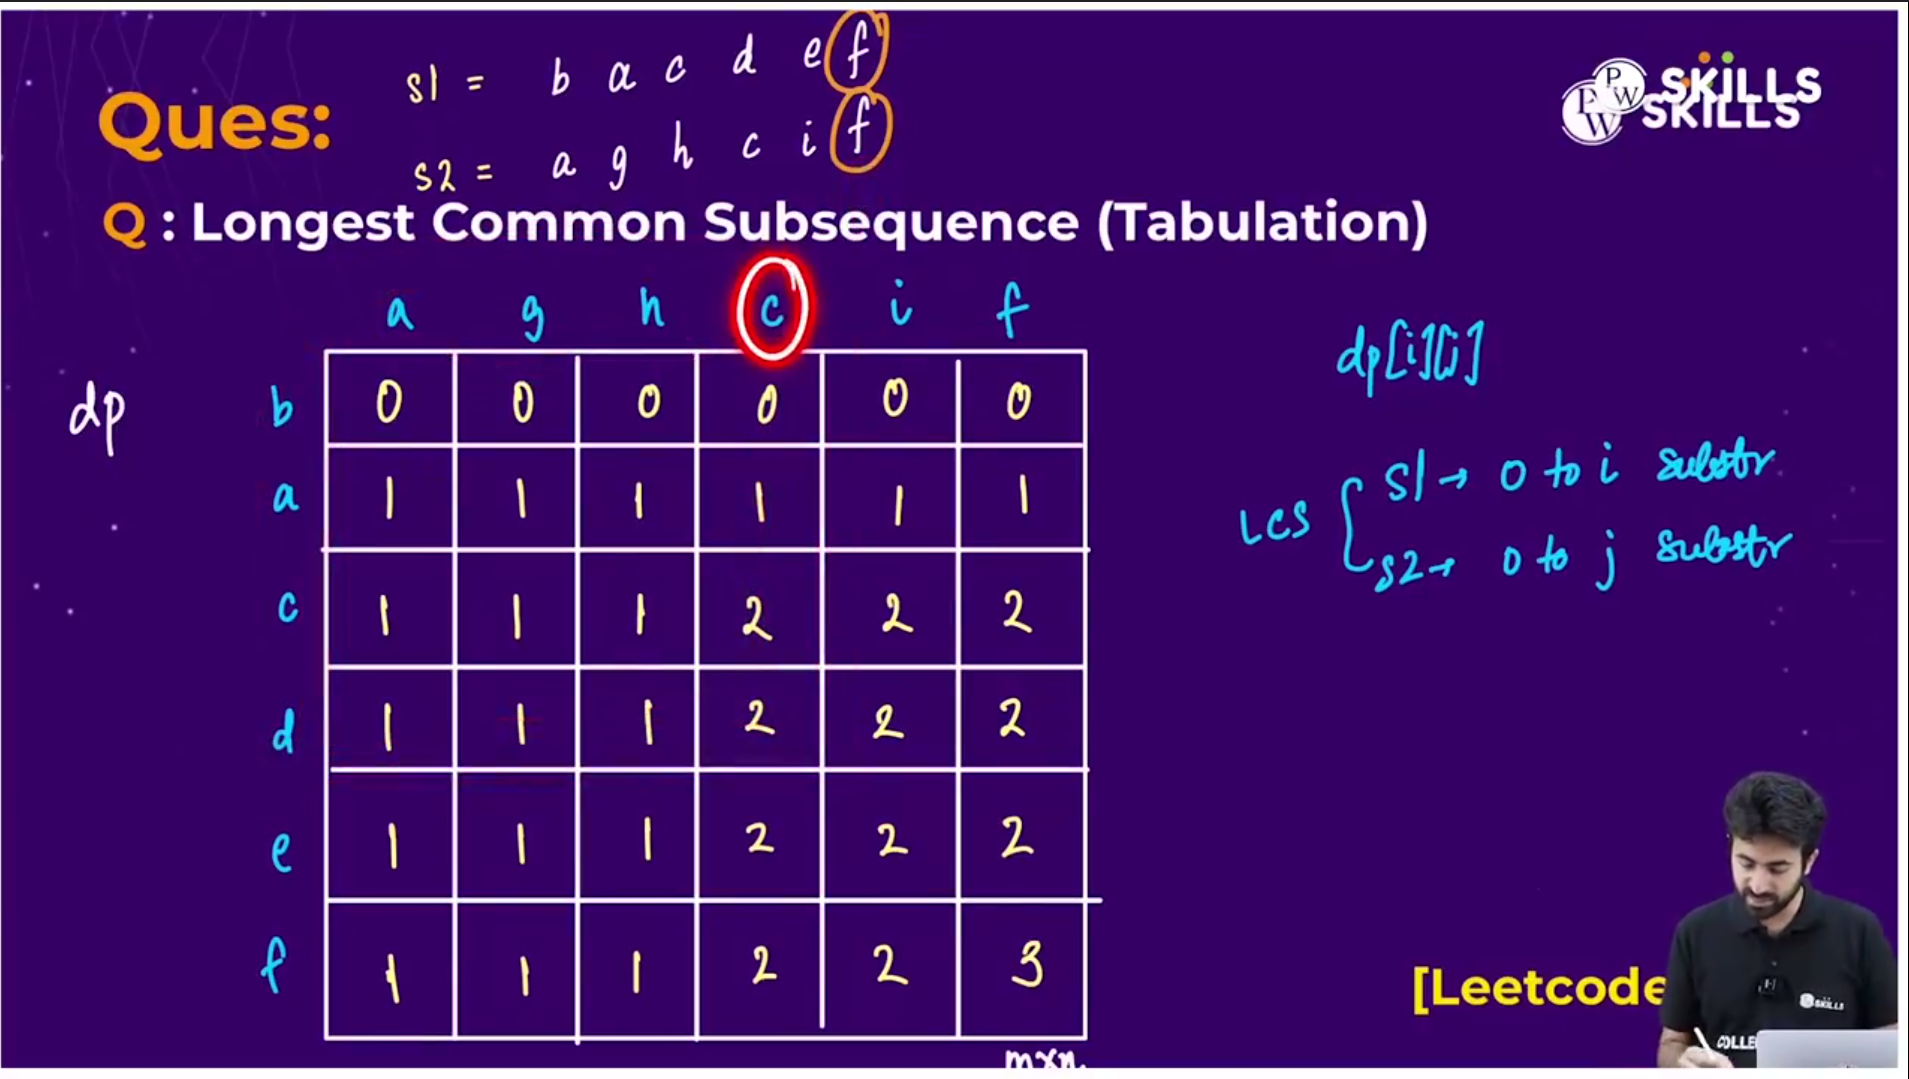

In [ ]:
# TODO: Space optimization
class Solution:
    def longestCommonSubsequence(self, text1: str, text2: str) -> int:
        m, n = len(text1), len(text2)

        dp = [[0] * (n + 1) for _ in range(2)]

        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if text1[i - 1] == text2[j - 1]:
                    dp[1][j] = 1 + dp[0][j - 1]
                else:
                    dp[1][j] = max(dp[1][j - 1], dp[0][j])

            # Copy current row to previous row
            for j in range(n + 1):
                dp[0][j] = dp[1][j]

        return dp[1][n]

In [22]:
text1 = "abcde"
text2 = "ace" 

obj = Solution()
obj.longestCommonSubsequence(text1,text2)

3

# `Printing LCS`

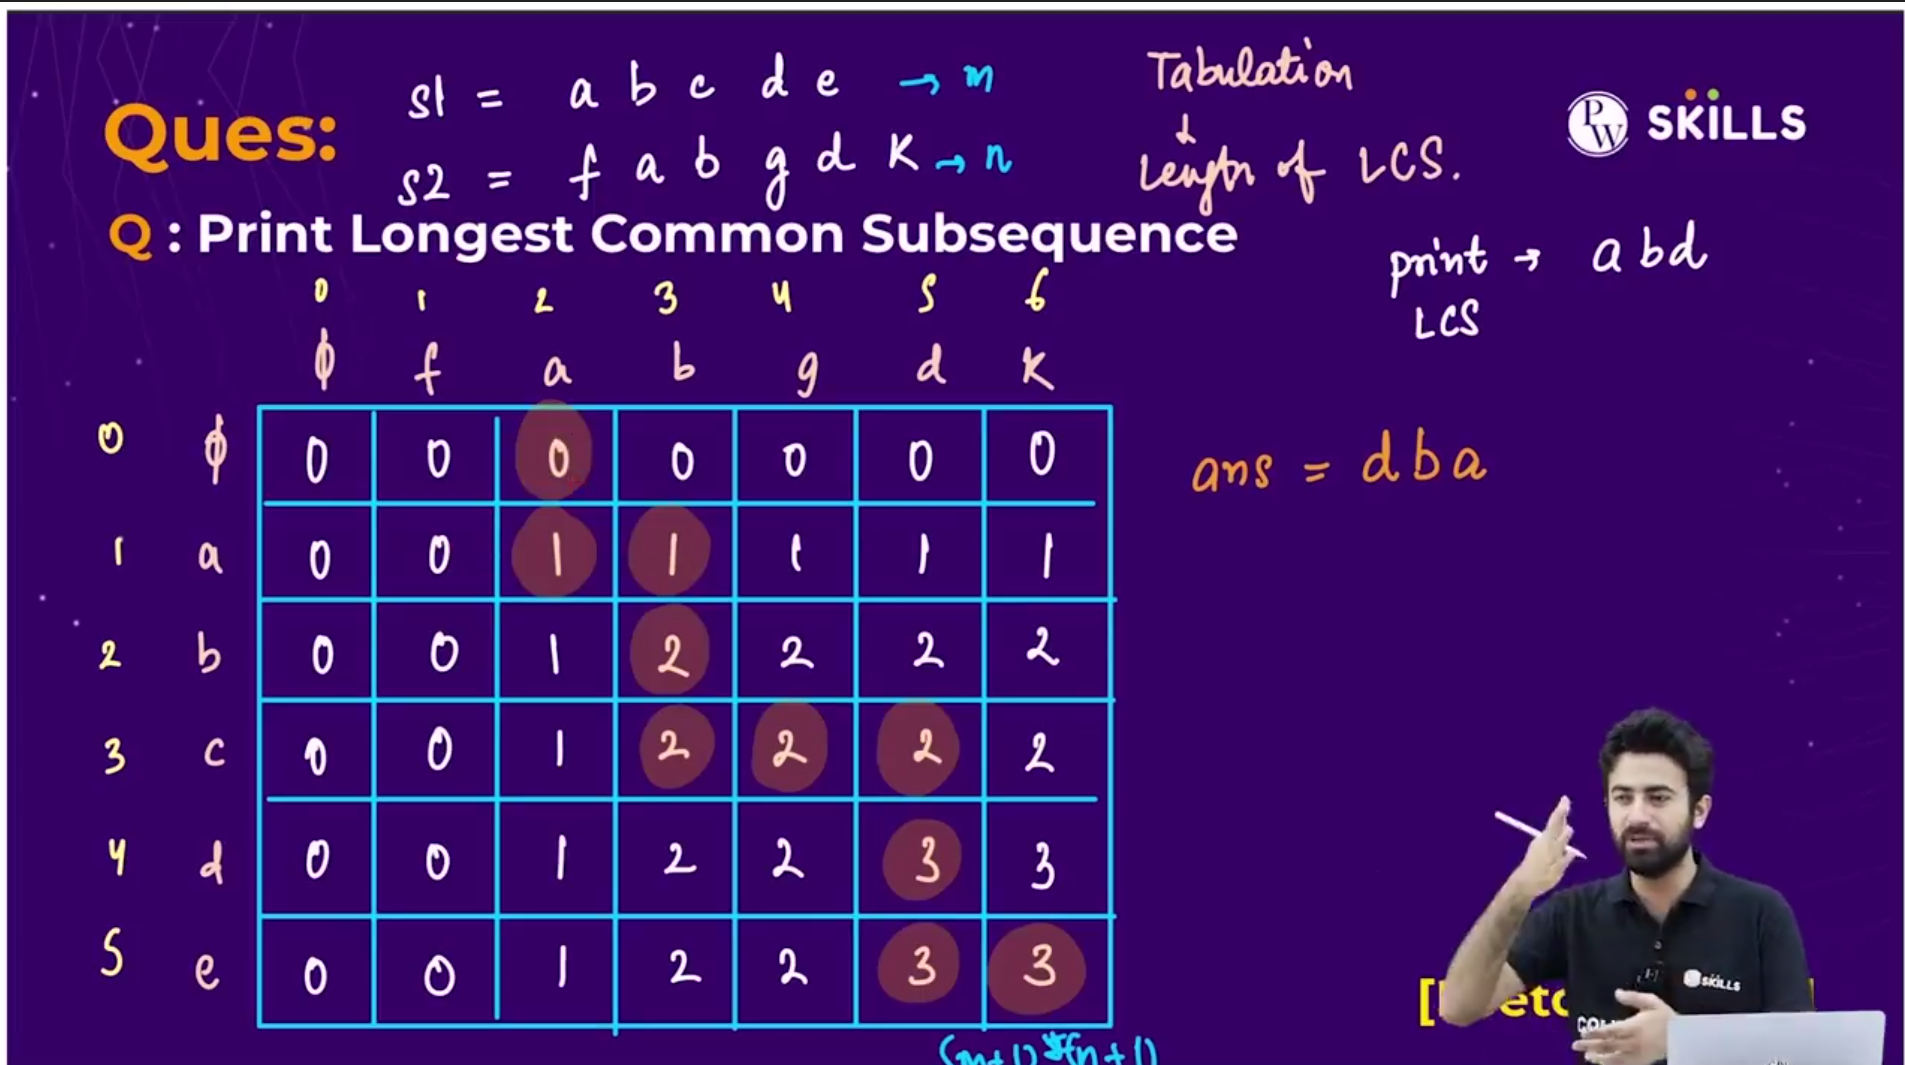

In [ ]:
# 1. Starting from last row and col cell
# 2. if x and y axis char matches append into the string and look for max number from above and left cell
# 3. Keep going and appending the char if found same
# 4. Once 1st row and 1st col id been reached stop
# 5. At the end reverse the string

In [27]:
class Solution:
    def longestCommonSubsequence(self, text1: str, text2: str) -> int:
        m, n = len(text1), len(text2)

        dp = [[0] * (n + 1) for _ in range(m + 1)]

        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if text1[i - 1] == text2[j - 1]:
                    dp[i][j] = 1 + dp[i - 1][j - 1]
                else:
                    dp[i][j] = max(dp[i][j - 1], dp[i - 1][j])

        str = ""
        i = m
        j = n

        while i > 0 and j > 0:
            if text1[i-1] == text2[j-1]:
                str += text1[i-1]
            if dp[i-1][j] > dp[i][j-1]:
                i -= 1
            else:
                j -= 1
        print(str[::-1])
        return dp[m][n]

In [28]:
text1 = "abcde"
text2 = "ace" 

obj = Solution()
obj.longestCommonSubsequence(text1,text2)

ace


3